In [1]:
import pandas as pd

df = pd.read_csv('student_performance.csv')
df.head()

,student_id,math_score,reading_score,writing_score,attendance_rate
0,1,85.0,88.0,90.0,95
1,2,78.0,72.0,75.0,88
2,3,92.0,95.0,94.0,98
3,4,65.0,68.0,64.0,80
4,5,110.0,102.0,105.0,99


In [2]:
df.isnull().sum()

student_id         0
math_score         1
reading_score      1
writing_score      1
attendance_rate    0
dtype: int64

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       25 non-null     int64  
 1   math_score       24 non-null     float64
 2   reading_score    24 non-null     float64
 3   writing_score    24 non-null     float64
 4   attendance_rate  25 non-null     int64  
dtypes: float64(3), int64(2)
memory usage: 1.1 KB


In [4]:
df['math_score']=df['math_score'].fillna(df['math_score'].median())
df['reading_score']=df['reading_score'].fillna(df['reading_score'].median())
df['writing_score'] = df['writing_score'].fillna(df['writing_score'].median())

df.isnull().sum()

student_id         0
math_score         0
reading_score      0
writing_score      0
attendance_rate    0
dtype: int64

math_score            Axes(0.125,0.53;0.227941x0.35)
writing_score      Axes(0.398529,0.53;0.227941x0.35)
reading_score      Axes(0.672059,0.53;0.227941x0.35)
attendance_rate       Axes(0.125,0.11;0.227941x0.35)
dtype: object

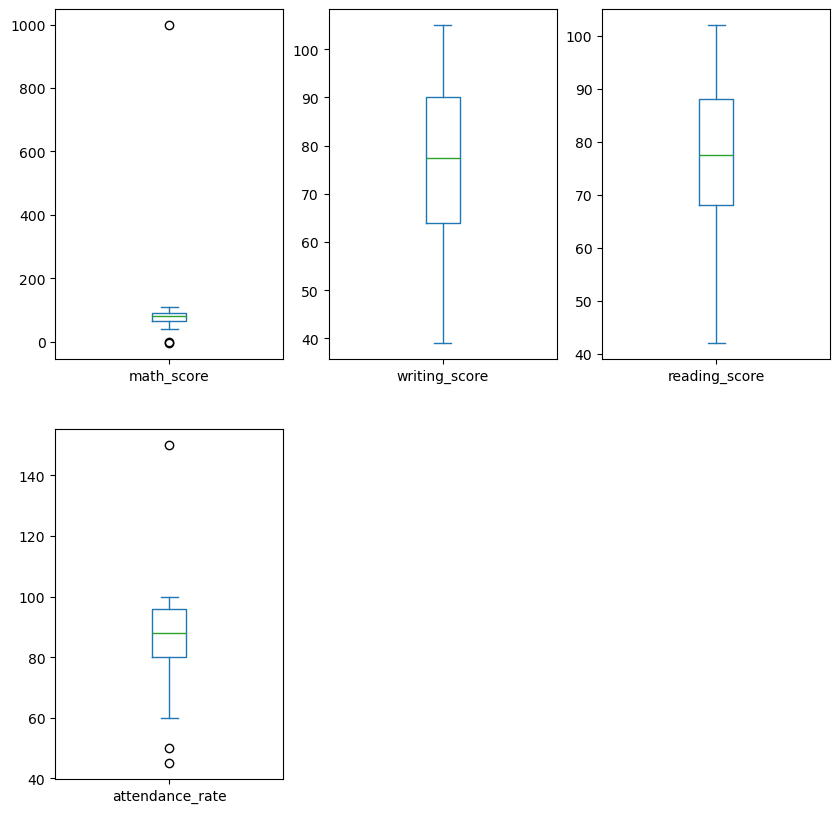

In [5]:
df.plot(column=['math_score','writing_score','reading_score','attendance_rate'],kind='box',subplots=True, layout=(2, 3),figsize=(10,10))

# shows outliers as circles outside range 

In [6]:
import numpy as np

outlier_indexes_att = np.concatenate((
    np.where(df['attendance_rate'] > 100)[0],
    np.where(df['attendance_rate'] < 60)[0]
))

attendance_rates = df.iloc[outlier_indexes_att]['attendance_rate']
print(attendance_rates)


20    150
9      45
18     50
Name: attendance_rate, dtype: int64


In [7]:
q1 = np.percentile(df['math_score'], 25)
q3 = np.percentile(df['math_score'], 75)

IQR = q3 - q1

upper_bound = q3 + IQR*1.5
lower_bound = q1 - IQR*1.5

for idx, val in df['math_score'].items():
    if (val > upper_bound or val < lower_bound):
        print(idx, val)

9 0.0
12 999.0
24 -5.0


In [8]:
z_scores = (df['attendance_rate'] - df['attendance_rate'].mean()) / df['attendance_rate'].std()

threshold = 1.5

outliers = df[np.abs(z_scores) > threshold]

print(outliers['attendance_rate'])

9      45
18     50
20    150
Name: attendance_rate, dtype: int64


In [9]:
# remove by deleting
new_df = df.copy()
for i in outlier_indexes_att:
    new_df = new_df.drop(i)
    
new_df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 22 entries, 0 to 24
Data columns (total 5 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   student_id       22 non-null     int64  
 1   math_score       22 non-null     float64
 2   reading_score    22 non-null     float64
 3   writing_score    22 non-null     float64
 4   attendance_rate  22 non-null     int64  
dtypes: float64(3), int64(2)
memory usage: 1.0 KB


In [10]:
tenth = np.percentile(df['attendance_rate'],10)
ninety = np.percentile(df['attendance_rate'],90)

new_df = df.copy()

new_df['attendance_rate'] = np.where(new_df['attendance_rate'] > ninety, ninety ,new_df['attendance_rate'])
new_df['attendance_rate'] = np.where(new_df['attendance_rate'] < tenth, tenth ,new_df['attendance_rate'])

print("ninetieth percentile: ", ninety)
print("tenth percentile: ", tenth)
display(new_df)

ninetieth percentile:  98.6
tenth percentile:  64.0


,student_id,math_score,reading_score,writing_score,attendance_rate
0,1,85.0,88.0,90.0,95.0
1,2,78.0,72.0,75.0,88.0
2,3,92.0,95.0,94.0,98.0
3,4,65.0,68.0,64.0,80.0
4,5,110.0,102.0,105.0,98.6
5,6,55.0,77.5,58.0,76.0
6,7,88.0,85.0,87.0,92.0
7,8,40.0,42.0,39.0,64.0
8,9,95.0,98.0,96.0,97.0
9,10,0.0,65.0,63.0,64.0


In [11]:
median = new_df['math_score'].median()

for idx, val in new_df['math_score'].items():
    if (val > upper_bound or val < lower_bound):
        new_df['math_score'][idx] = median
        # new_df.loc[idx, 'math_score'] = median
        
display(new_df)

/tmp/ipykernel_192455/367125709.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['math_score'][idx] = median
/tmp/ipykernel_192455/367125709.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['math_score'][idx] = median
/tmp/ipykernel_192455/367125709.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  new_df['math_score'][idx] = median


,student_id,math_score,reading_score,writing_score,attendance_rate
0,1,85.0,88.0,90.0,95.0
1,2,78.0,72.0,75.0,88.0
2,3,92.0,95.0,94.0,98.0
3,4,65.0,68.0,64.0,80.0
4,5,110.0,102.0,105.0,98.6
5,6,55.0,77.5,58.0,76.0
6,7,88.0,85.0,87.0,92.0
7,8,40.0,42.0,39.0,64.0
8,9,95.0,98.0,96.0,97.0
9,10,79.5,65.0,63.0,64.0


array([[<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>],
       [<Axes: ylabel='Frequency'>, <Axes: ylabel='Frequency'>,
        <Axes: ylabel='Frequency'>]], dtype=object)

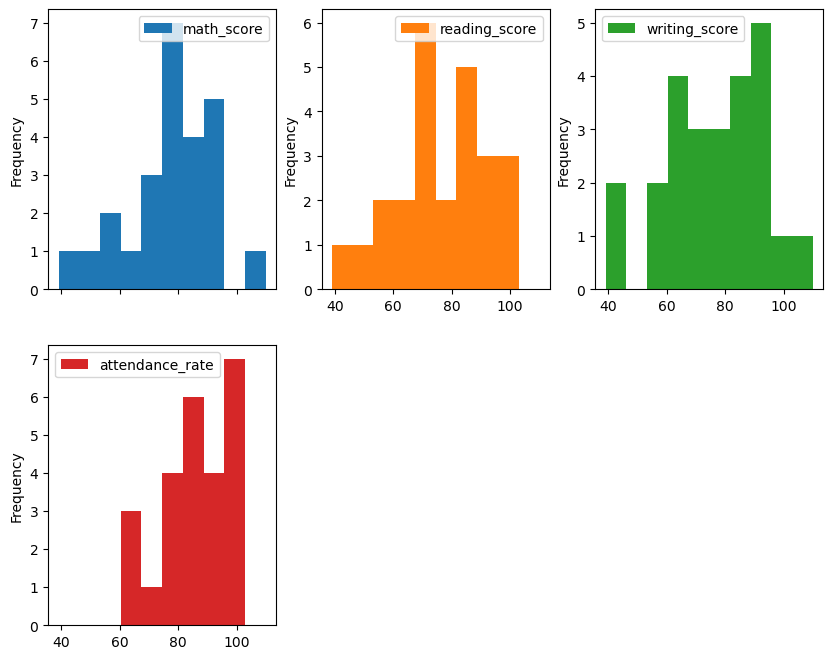

In [19]:
new_df.plot(column = ['math_score','reading_score','writing_score','attendance_rate' ],subplots=True, kind='hist', figsize=(10,8), layout=(2,3))


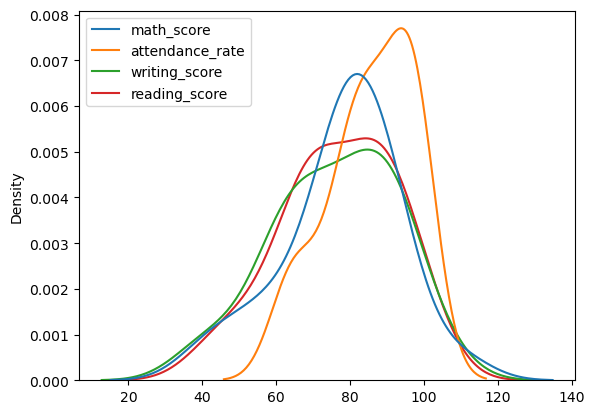

In [28]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.kdeplot(data=new_df[['math_score', 'attendance_rate','writing_score', 'reading_score']])
plt.show()